In [1]:
# Loading in libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [3]:
# Importing the csv file as a dataframe, making a copy, and previewing the first 5 rows
df = pd.read_csv("../data/raw/team_summaries.csv")
original = df.copy()

df.head()

,season,lg,team,abbreviation,playoffs,age,w,l,pw,pl,mov,sos,srs,o_rtg,d_rtg,n_rtg,pace,f_tr,x3p_ar,ts_percent,e_fg_percent,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga,arena,attend,attend_g
0,2025,NBA,Atlanta Hawks,ATL,True,24.9,40.0,42.0,38.0,44.0,-1.13,-0.28,-1.41,114.6,115.7,-1.1,102.6,0.252,0.410,0.579,0.546,13.2,26.3,0.196,0.560,13.8,76.0,0.202,State Farm Arena,657613.0,16440.0
1,2025,NBA,Boston Celtics,BOS,True,28.9,61.0,21.0,62.0,20.0,9.11,-0.83,8.28,120.6,111.1,9.5,95.7,0.212,0.536,0.591,0.561,10.8,25.7,0.169,0.522,11.6,76.0,0.154,TD Garden,785396.0,19156.0
2,2025,NBA,Brooklyn Nets,BRK,False,24.7,26.0,56.0,23.0,59.0,-7.11,0.16,-6.95,108.5,115.8,-7.3,96.4,0.240,0.458,0.552,0.516,13.7,24.5,0.189,0.557,13.7,75.0,0.218,Barclays Center,713304.0,17398.0
3,2025,NBA,Chicago Bulls,CHI,True,25.2,39.0,43.0,37.0,45.0,-1.56,-0.27,-1.83,114.1,115.6,-1.5,102.8,0.214,0.457,0.585,0.553,12.7,22.3,0.173,0.539,10.8,76.6,0.178,United Center,825659.0,20138.0
4,2025,NBA,Charlotte Hornets,CHO,False,25.1,19.0,63.0,20.0,62.0,-9.11,0.01,-9.10,107.3,116.6,-9.3,97.6,0.222,0.430,0.537,0.503,13.7,26.5,0.174,0.547,11.9,74.5,0.190,Spectrum Center,703935.0,17169.0


In [4]:
# Creating a dataframe that contains rows from the 2014-2023 seasons for each team
teams_14_23 = df[
    (df["season"] >= 2014) & (df["season"] < 2024) & (df["team"] != "League Average")
].copy()

teams_14_23.head()

,season,lg,team,abbreviation,playoffs,age,w,l,pw,pl,mov,sos,srs,o_rtg,d_rtg,n_rtg,pace,f_tr,x3p_ar,ts_percent,e_fg_percent,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga,arena,attend,attend_g
62,2023,NBA,Atlanta Hawks,ATL,True,24.9,41.0,41.0,42.0,40.0,0.29,0.02,0.32,116.6,116.3,0.3,100.7,0.244,0.331,0.579,0.541,11.2,25.1,0.200,0.552,12.4,75.8,0.206,State Farm Arena,719787.0,17556.0
63,2023,NBA,Boston Celtics,BOS,True,27.4,57.0,25.0,57.0,25.0,6.52,-0.15,6.38,118.0,111.5,6.5,98.5,0.243,0.480,0.600,0.566,12.0,22.1,0.197,0.528,11.3,78.5,0.180,TD Garden,785396.0,19156.0
64,2023,NBA,Brooklyn Nets,BRK,True,28.0,45.0,37.0,43.0,39.0,0.85,0.18,1.03,115.0,114.1,0.9,98.3,0.260,0.397,0.598,0.562,12.7,19.6,0.208,0.530,12.2,73.7,0.212,Barclays Center,724439.0,17669.0
65,2023,NBA,Chicago Bulls,CHI,False,27.5,40.0,42.0,44.0,38.0,1.29,0.07,1.37,113.5,112.2,1.3,98.5,0.251,0.333,0.587,0.550,12.2,20.1,0.203,0.544,13.5,77.8,0.197,United Center,841632.0,20528.0
66,2023,NBA,Charlotte Hornets,CHO,False,25.3,27.0,55.0,26.0,56.0,-6.24,0.35,-5.89,109.2,115.3,-6.1,100.8,0.261,0.360,0.550,0.516,12.3,23.8,0.195,0.544,12.5,75.5,0.211,Spectrum Center,702052.0,17123.0


In [5]:
# Getting a summary of the data and checking for duplicate rows and null values
print(f"There are {teams_14_23.duplicated().sum()} duplicate rows.\n")

print(f"Dataset Information:\n")
teams_14_23.info()

# There are no duplicate rows
# There are 4 null values in the 'arena' and 'attend_g' columns. Those missing values are unimportant for the analysis.

There are 0 duplicate rows.

Dataset Information:

<class 'pandas.DataFrame'>
Index: 300 entries, 62 to 370
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            300 non-null    int64  
 1   lg                300 non-null    str    
 2   team              300 non-null    str    
 3   abbreviation      300 non-null    str    
 4   playoffs          300 non-null    bool   
 5   age               300 non-null    float64
 6   w                 300 non-null    float64
 7   l                 300 non-null    float64
 8   pw                300 non-null    float64
 9   pl                300 non-null    float64
 10  mov               300 non-null    float64
 11  sos               300 non-null    float64
 12  srs               300 non-null    float64
 13  o_rtg             300 non-null    float64
 14  d_rtg             300 non-null    float64
 15  n_rtg             300 non-null    float64
 16  pace    

In [6]:
# Summary statistics for the numeric columns
teams_14_23.describe().round(2)

,season,age,w,l,pw,pl,mov,sos,srs,o_rtg,d_rtg,n_rtg,pace,f_tr,x3p_ar,ts_percent,e_fg_percent,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga,attend,attend_g
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,296.00,296.00
mean,2018.50,26.35,39.93,39.93,39.98,39.88,-0.02,-0.00,-0.02,109.61,109.62,-0.01,97.43,0.26,0.34,0.56,0.52,12.82,23.48,0.20,0.52,12.82,76.50,0.20,652671.68,16309.01
std,2.88,1.73,12.00,11.79,11.57,11.37,4.65,0.35,4.52,4.25,3.88,4.72,3.01,0.03,0.07,0.02,0.02,0.98,2.44,0.02,0.02,1.10,1.91,0.02,202870.29,4891.96
min,2014.00,22.10,10.00,9.00,15.00,15.00,-10.64,-0.93,-10.66,95.50,99.00,-10.50,89.90,0.19,0.17,0.49,0.46,9.90,17.90,0.14,0.46,10.30,71.00,0.16,5817.00,162.00
25%,2016.00,25.10,32.00,31.00,32.00,32.00,-3.04,-0.26,-2.96,106.10,107.00,-3.10,95.60,0.24,0.29,0.54,0.50,12.20,21.60,0.19,0.51,12.00,75.30,0.19,627413.00,15974.00
50%,2018.50,26.20,41.50,39.00,41.00,39.00,0.29,0.00,0.16,109.85,109.70,0.30,97.70,0.26,0.34,0.56,0.52,12.70,23.40,0.20,0.52,12.80,76.50,0.20,703841.00,17449.50
75%,2021.00,27.42,48.25,48.25,49.00,48.00,3.19,0.24,3.02,112.90,112.50,3.30,99.50,0.28,0.39,0.57,0.54,13.42,24.92,0.22,0.54,13.60,77.80,0.22,769176.50,19018.50
max,2023.00,30.60,73.00,72.00,67.00,66.00,11.63,0.96,11.35,119.40,120.00,11.60,105.10,0.39,0.52,0.61,0.57,16.00,31.40,0.28,0.58,16.30,81.60,0.26,894659.00,21821.00


In [7]:
# Checking the 'playoffs' column to ensure correct values
teams_14_23["playoffs"].value_counts().reset_index()

# Count of 'playoffs' being True should be 160 over the 10 years, but it is only 144

,playoffs,count
0,True,160
1,False,140


In [8]:
# Fixing incorrect values for the 'playoffs' column in the year 2023
playoff_list_23 = [
    "DEN",
    "MIN",
    "PHO",
    "LAC",
    "SAC",
    "GSW",
    "MEM",
    "LAL",
    "MIL",
    "MIA",
    "CLE",
    "NYK",
    "PHI",
    "BRK",
    "BOS",
    "ATL",
]

teams_14_23["playoffs"] = np.where(
    (teams_14_23["abbreviation"].isin(playoff_list_23))
    & (teams_14_23["season"] == 2023),
    True,
    teams_14_23["playoffs"],
)

teams_14_23["playoffs"].value_counts().reset_index()

# The variable is now accurate

,playoffs,count
0,True,160
1,False,140


In [9]:
# Converting the 'playoffs' column to integer (True -> 1, False -> 0) for future model use
teams_14_23["playoffs"] = teams_14_23["playoffs"].astype(int)

teams_14_23["playoffs"].value_counts().reset_index()

,playoffs,count
0,1,160
1,0,140


In [10]:
# Adjusting the value of the 'e_fg_percent' and 'ft_fga' columns to make it more consistent with the other "Four Factors" variables that will be used in the models
teams_14_23["e_fg_percent"] = teams_14_23["e_fg_percent"] * 100
teams_14_23["ft_fga"] = teams_14_23["ft_fga"] * 100

teams_14_23[["e_fg_percent", "tov_percent", "orb_percent", "ft_fga"]].head()

,e_fg_percent,tov_percent,orb_percent,ft_fga
62,54.1,11.2,25.1,20.0
63,56.6,12.0,22.1,19.7
64,56.2,12.7,19.6,20.8
65,55.0,12.2,20.1,20.3
66,51.6,12.3,23.8,19.5


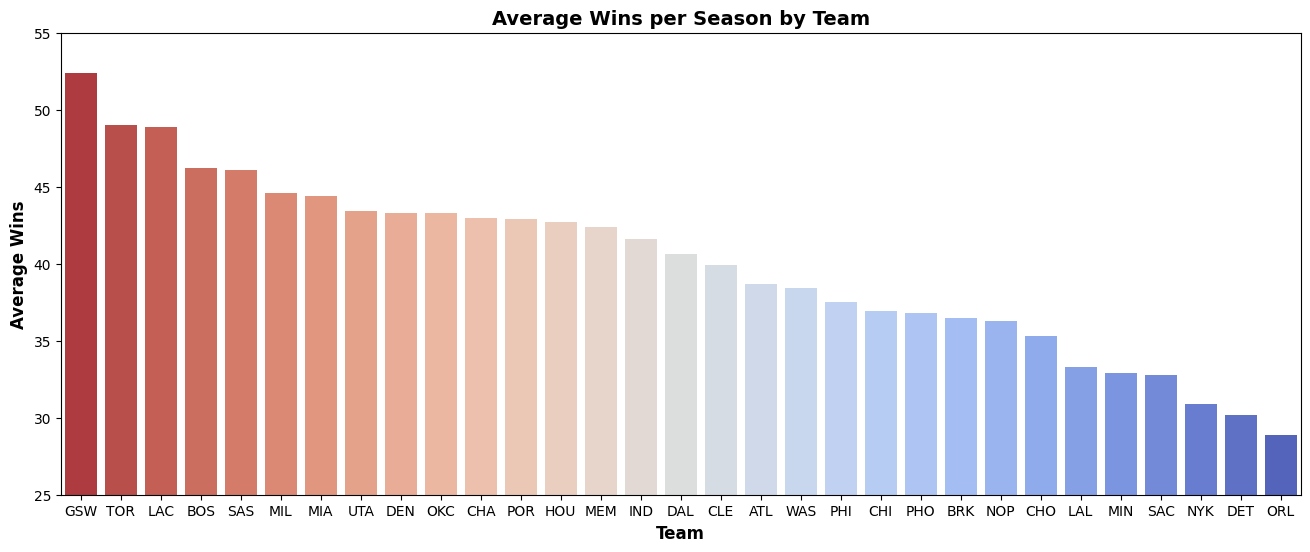

In [11]:
# Observing average wins for each team using a bar chart
teams_avg_wins = (
    teams_14_23.groupby("abbreviation")["w"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(16, 6))
sns.barplot(
    data=teams_avg_wins,
    x="abbreviation",
    y="w",
    hue="abbreviation",
    palette="coolwarm_r",
)
plt.ylim(25, 55)
plt.title("Average Wins per Season by Team", fontsize=14, weight="bold")
plt.xlabel("Team", fontsize=12, weight="bold")
plt.ylabel("Average Wins", fontsize=12, weight="bold")
plt.show()

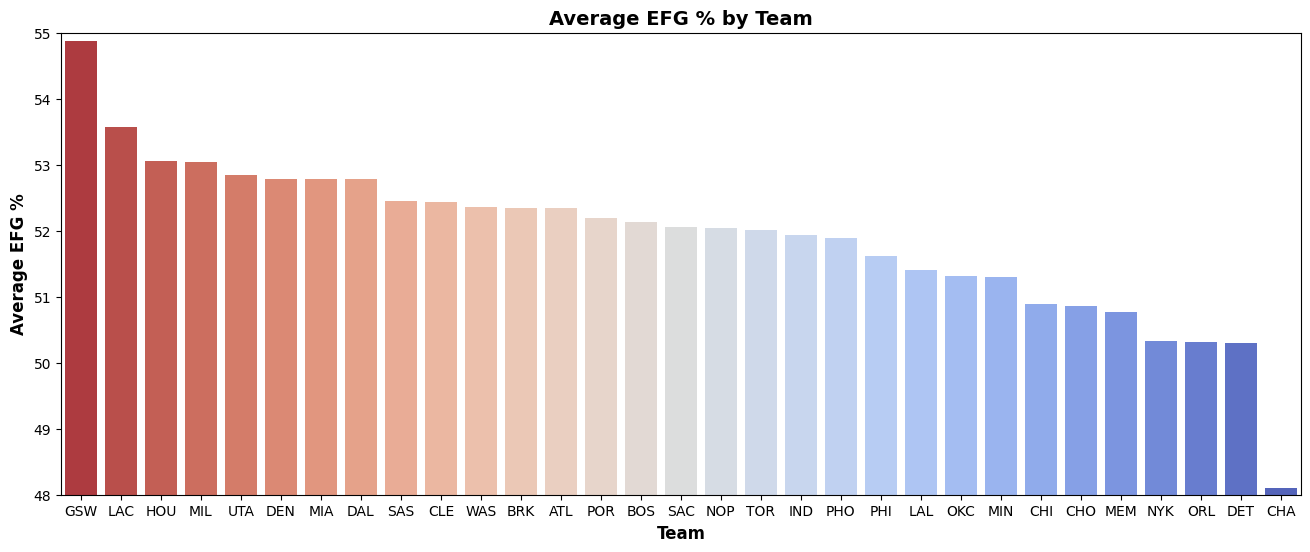

In [12]:
# Observing average effective field goal % for each team using a bar chart
teams_avg_efg = (
    teams_14_23.groupby("abbreviation")["e_fg_percent"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(16, 6))
sns.barplot(
    data=teams_avg_efg,
    x="abbreviation",
    y="e_fg_percent",
    hue="abbreviation",
    palette="coolwarm_r",
)
plt.ylim(48, 55)
plt.title("Average EFG % by Team", fontsize=14, weight="bold")
plt.xlabel("Team", fontsize=12, weight="bold")
plt.ylabel("Average EFG %", fontsize=12, weight="bold")
plt.show()

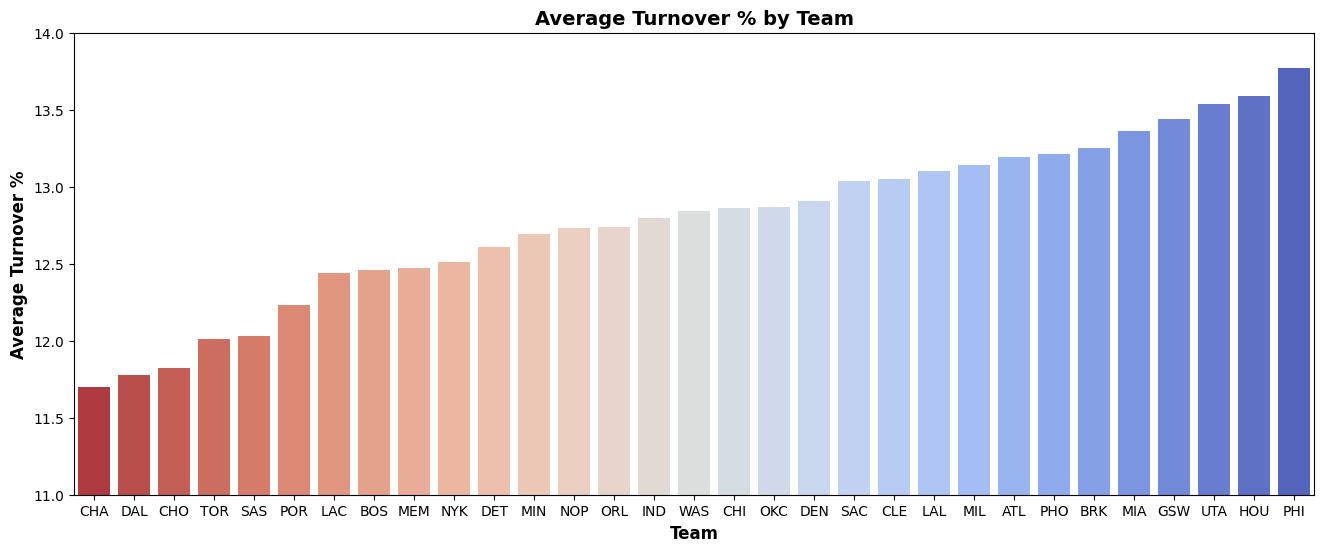

In [13]:
# Observing average turnover % for each team using a bar chart
teams_avg_tov = (
    teams_14_23.groupby("abbreviation")["tov_percent"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
plt.figure(figsize=(16, 6))
sns.barplot(
    data=teams_avg_tov,
    x="abbreviation",
    y="tov_percent",
    hue="abbreviation",
    palette="coolwarm_r",
)
plt.ylim(11, 14)
plt.title("Average Turnover % by Team", fontsize=14, weight="bold")
plt.xlabel("Team", fontsize=12, weight="bold")
plt.ylabel("Average Turnover %", fontsize=12, weight="bold")
plt.show()

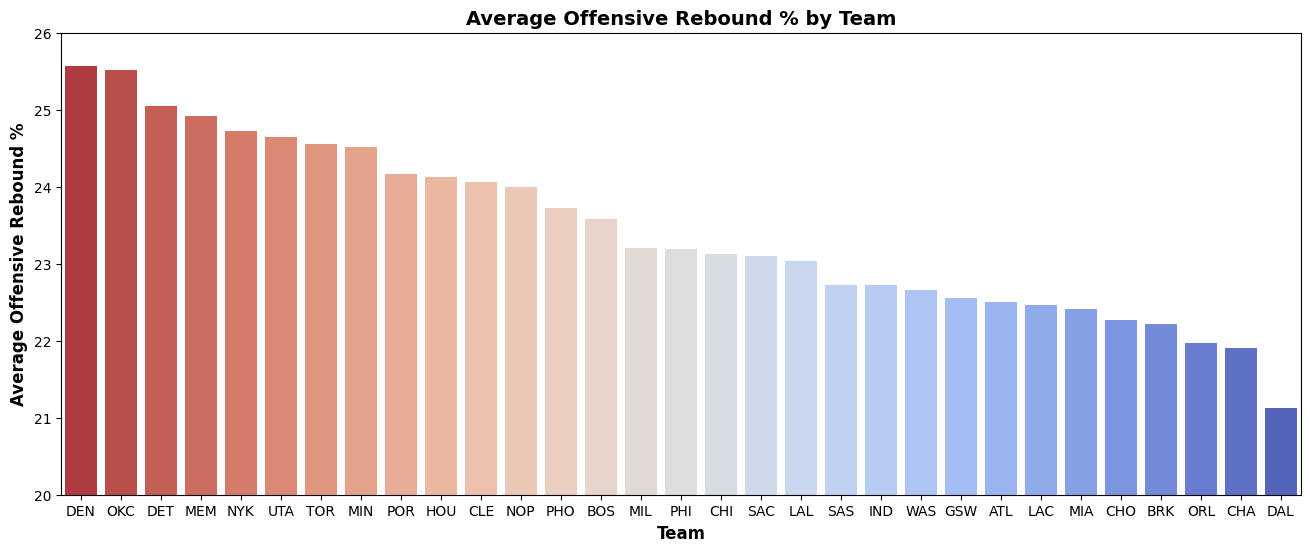

In [14]:
# Observing average offensive rebound % for each team using a bar chart
teams_avg_orb = (
    teams_14_23.groupby("abbreviation")["orb_percent"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(16, 6))
sns.barplot(
    data=teams_avg_orb,
    x="abbreviation",
    y="orb_percent",
    hue="abbreviation",
    palette="coolwarm_r",
)
plt.ylim(20, 26)
plt.title("Average Offensive Rebound % by Team", fontsize=14, weight="bold")
plt.xlabel("Team", fontsize=12, weight="bold")
plt.ylabel("Average Offensive Rebound %", fontsize=12, weight="bold")
plt.show()

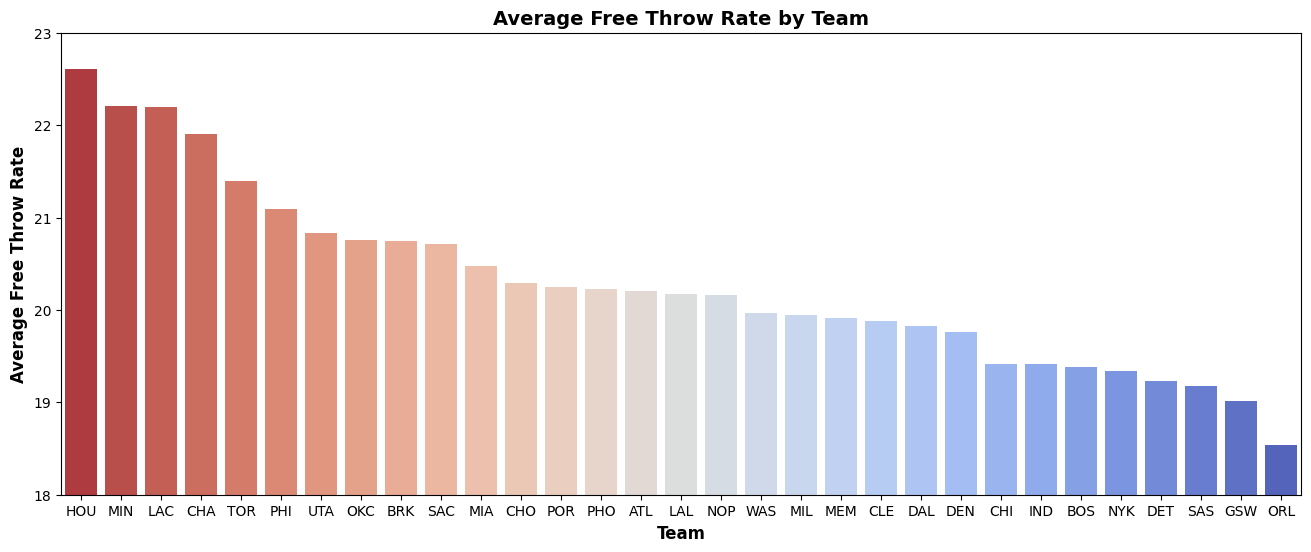

In [15]:
# Observing average free throw rate for each team using a bar chart
teams_avg_ftr = (
    teams_14_23.groupby("abbreviation")["ft_fga"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(16, 6))
sns.barplot(
    data=teams_avg_ftr,
    x="abbreviation",
    y="ft_fga",
    hue="abbreviation",
    palette="coolwarm_r",
)
plt.ylim(18, 23)
plt.title("Average Free Throw Rate by Team", fontsize=14, weight="bold")
plt.xlabel("Team", fontsize=12, weight="bold")
plt.ylabel("Average Free Throw Rate", fontsize=12, weight="bold")
plt.show()

In [16]:
# Creating the dataframe 'teams_24' that contains data for teams from the 2024 season to use as testing data

# Making the new dataframe and correcting the 'playoffs' column to ensure correct values
playoff_list_24 = [
    "CLE",
    "IND",
    "LAL",
    "MIA",
    "NOP",
    "NYK",
    "ORL",
    "PHO",
    "PHI",
    "OKC",
    "LAC",
    "DAL",
    "MIN",
    "DEN",
    "BOS",
    "MIL",
]

teams_24 = df[(df["season"] == 2024) & (df["team"] != "League Average")].copy()
teams_24.loc[teams_24["abbreviation"].isin(playoff_list_24), "playoffs"] = True

# Adjusting the values of the 'e_fg_percent' and 'ft_fga' to remain consistent with the 'teams_14_23' dataframe
teams_24["e_fg_percent"] = teams_24["e_fg_percent"] * 100
teams_24["ft_fga"] = teams_24["ft_fga"] * 100

# Converting 'playoffs' column to integer (True -> 1, False -> 0) for model use
teams_24["playoffs"] = teams_24["playoffs"].astype(int)

teams_24.head()

,season,lg,team,abbreviation,playoffs,age,w,l,pw,pl,mov,sos,srs,o_rtg,d_rtg,n_rtg,pace,f_tr,x3p_ar,ts_percent,e_fg_percent,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga,arena,attend,attend_g
31,2024,NBA,Atlanta Hawks,ATL,0,26.2,36.0,46.0,36.0,46.0,-2.18,-0.19,-2.38,117.2,119.4,-2.2,100.1,0.251,0.408,0.576,53.9,11.6,27.1,20.0,0.572,12.4,75.2,0.192,State Farm Arena,696418.0,16986.0
32,2024,NBA,Boston Celtics,BOS,1,28.2,64.0,18.0,66.0,16.0,11.34,-0.60,10.75,123.2,111.6,11.6,97.2,0.224,0.471,0.609,57.8,10.8,24.9,18.0,0.523,10.8,76.3,0.145,TD Garden,785396.0,19156.0
33,2024,NBA,Brooklyn Nets,BRK,0,26.1,32.0,50.0,34.0,48.0,-2.89,-0.13,-3.02,113.2,116.1,-2.9,96.9,0.234,0.412,0.561,53.1,11.8,25.2,17.7,0.543,11.4,76.0,0.193,Barclays Center,720291.0,17568.0
34,2024,NBA,Chicago Bulls,CHI,0,28.1,39.0,43.0,37.0,45.0,-1.44,-0.33,-1.77,114.9,116.3,-1.4,96.3,0.236,0.358,0.568,53.4,11.0,25.1,18.7,0.556,12.7,76.4,0.195,United Center,845620.0,20625.0
35,2024,NBA,Charlotte Hornets,CHO,0,25.1,21.0,61.0,18.0,64.0,-10.24,0.13,-10.12,109.3,119.8,-10.5,97.3,0.212,0.391,0.560,52.9,12.6,21.1,16.7,0.572,12.3,74.5,0.188,Spectrum Center,674400.0,16449.0


In [17]:
# Confirming the 'playoff' column is accurate
teams_24["playoffs"].value_counts().reset_index()

,playoffs,count
0,1,16
1,0,14


In [18]:
# Saving clean dataframes as csv files for future use
teams_14_23.to_csv("../data/processed/teams_14_23.csv", index=False)
teams_24.to_csv("../data/processed/teams_24.csv", index=False)